In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

!wget -O Housing.csv https://raw.githubusercontent.com/Turbonik/AILab1/main/Housing.csv


--2026-09-17 13:29:11--  https://raw.githubusercontent.com/Turbonik/AILab1/main/Housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29981 (29K) [text/plain]
Saving to: ‘Housing.csv’

Housing.csv         100%[===================>]  29.28K  --.-KB/s    in 0.007s  

2026-09-17 13:29:11 (4.14 MB/s) - ‘Housing.csv’ saved [29981/29981]



## Описание датасета

В работе используется датасет Housing.csv, содержащий информацию об объектах недвижимости.
Всего 545 строк и 13 признаков. Целевая переменная — price.
Признаки включают числовые (area, bedrooms, bathrooms, stories, parking) и категориальные (mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, furnishingstatus).


Статистика по числовым признакам:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  

Медианы числовых признаков:
price        4340000.0
area            4600.0
bedrooms           3.0
bathrooms          1.0
storie

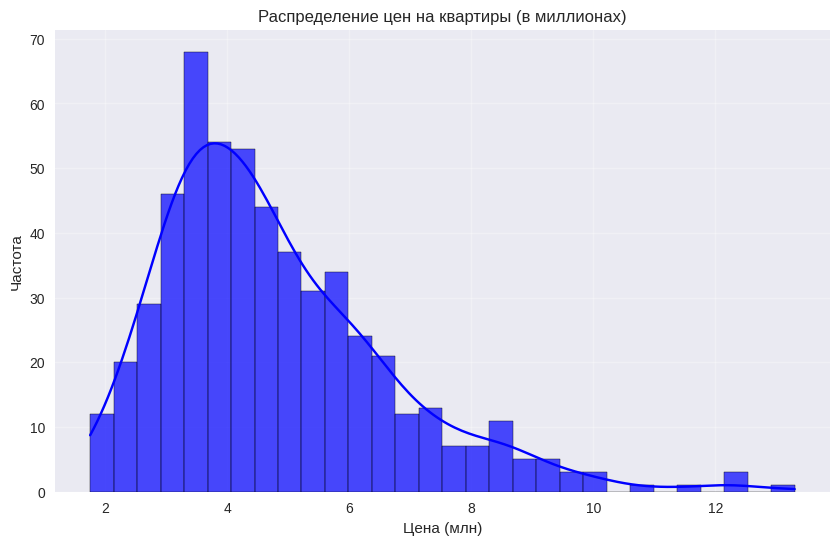

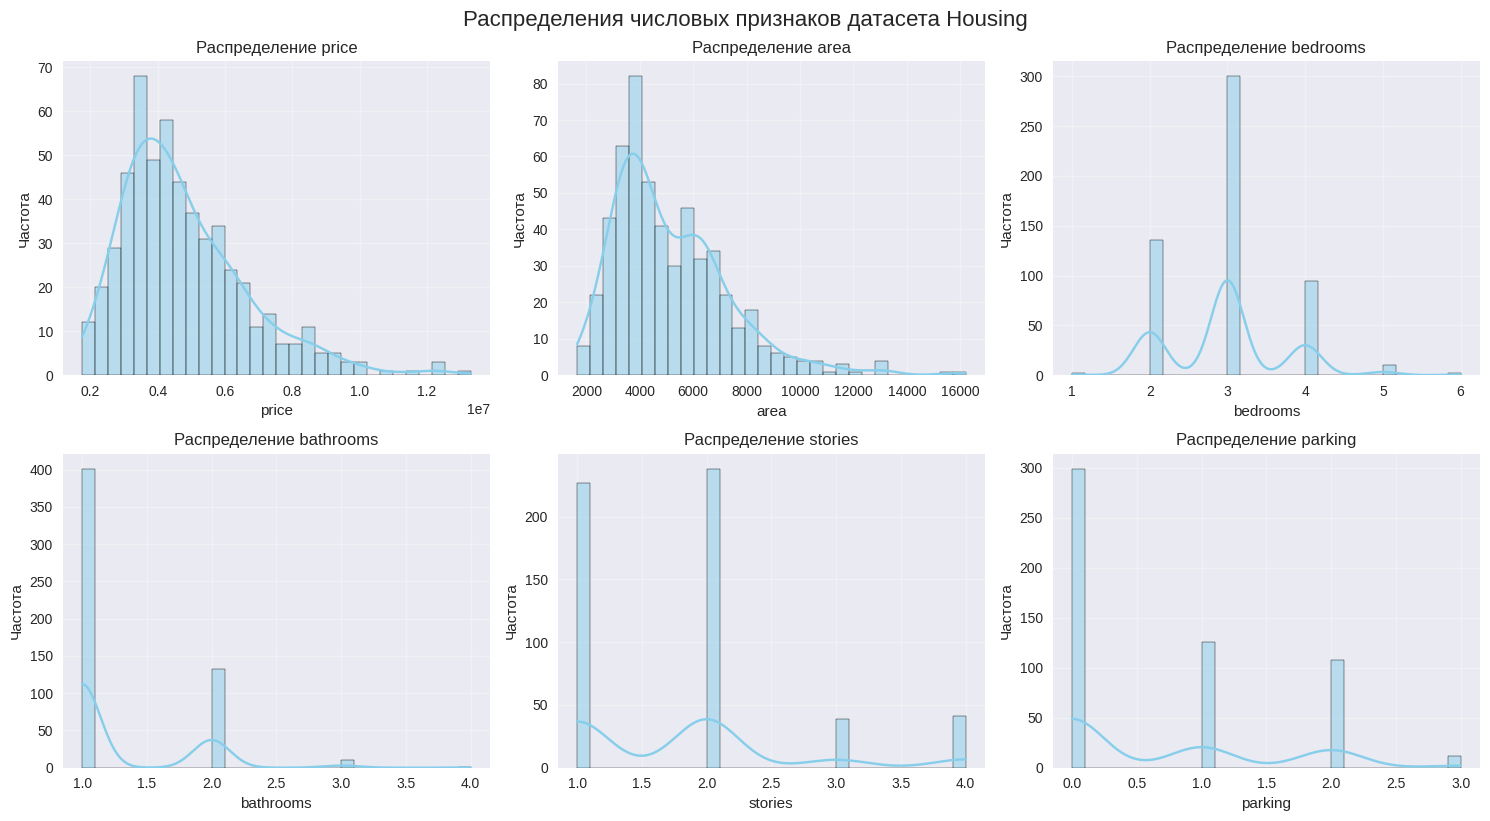

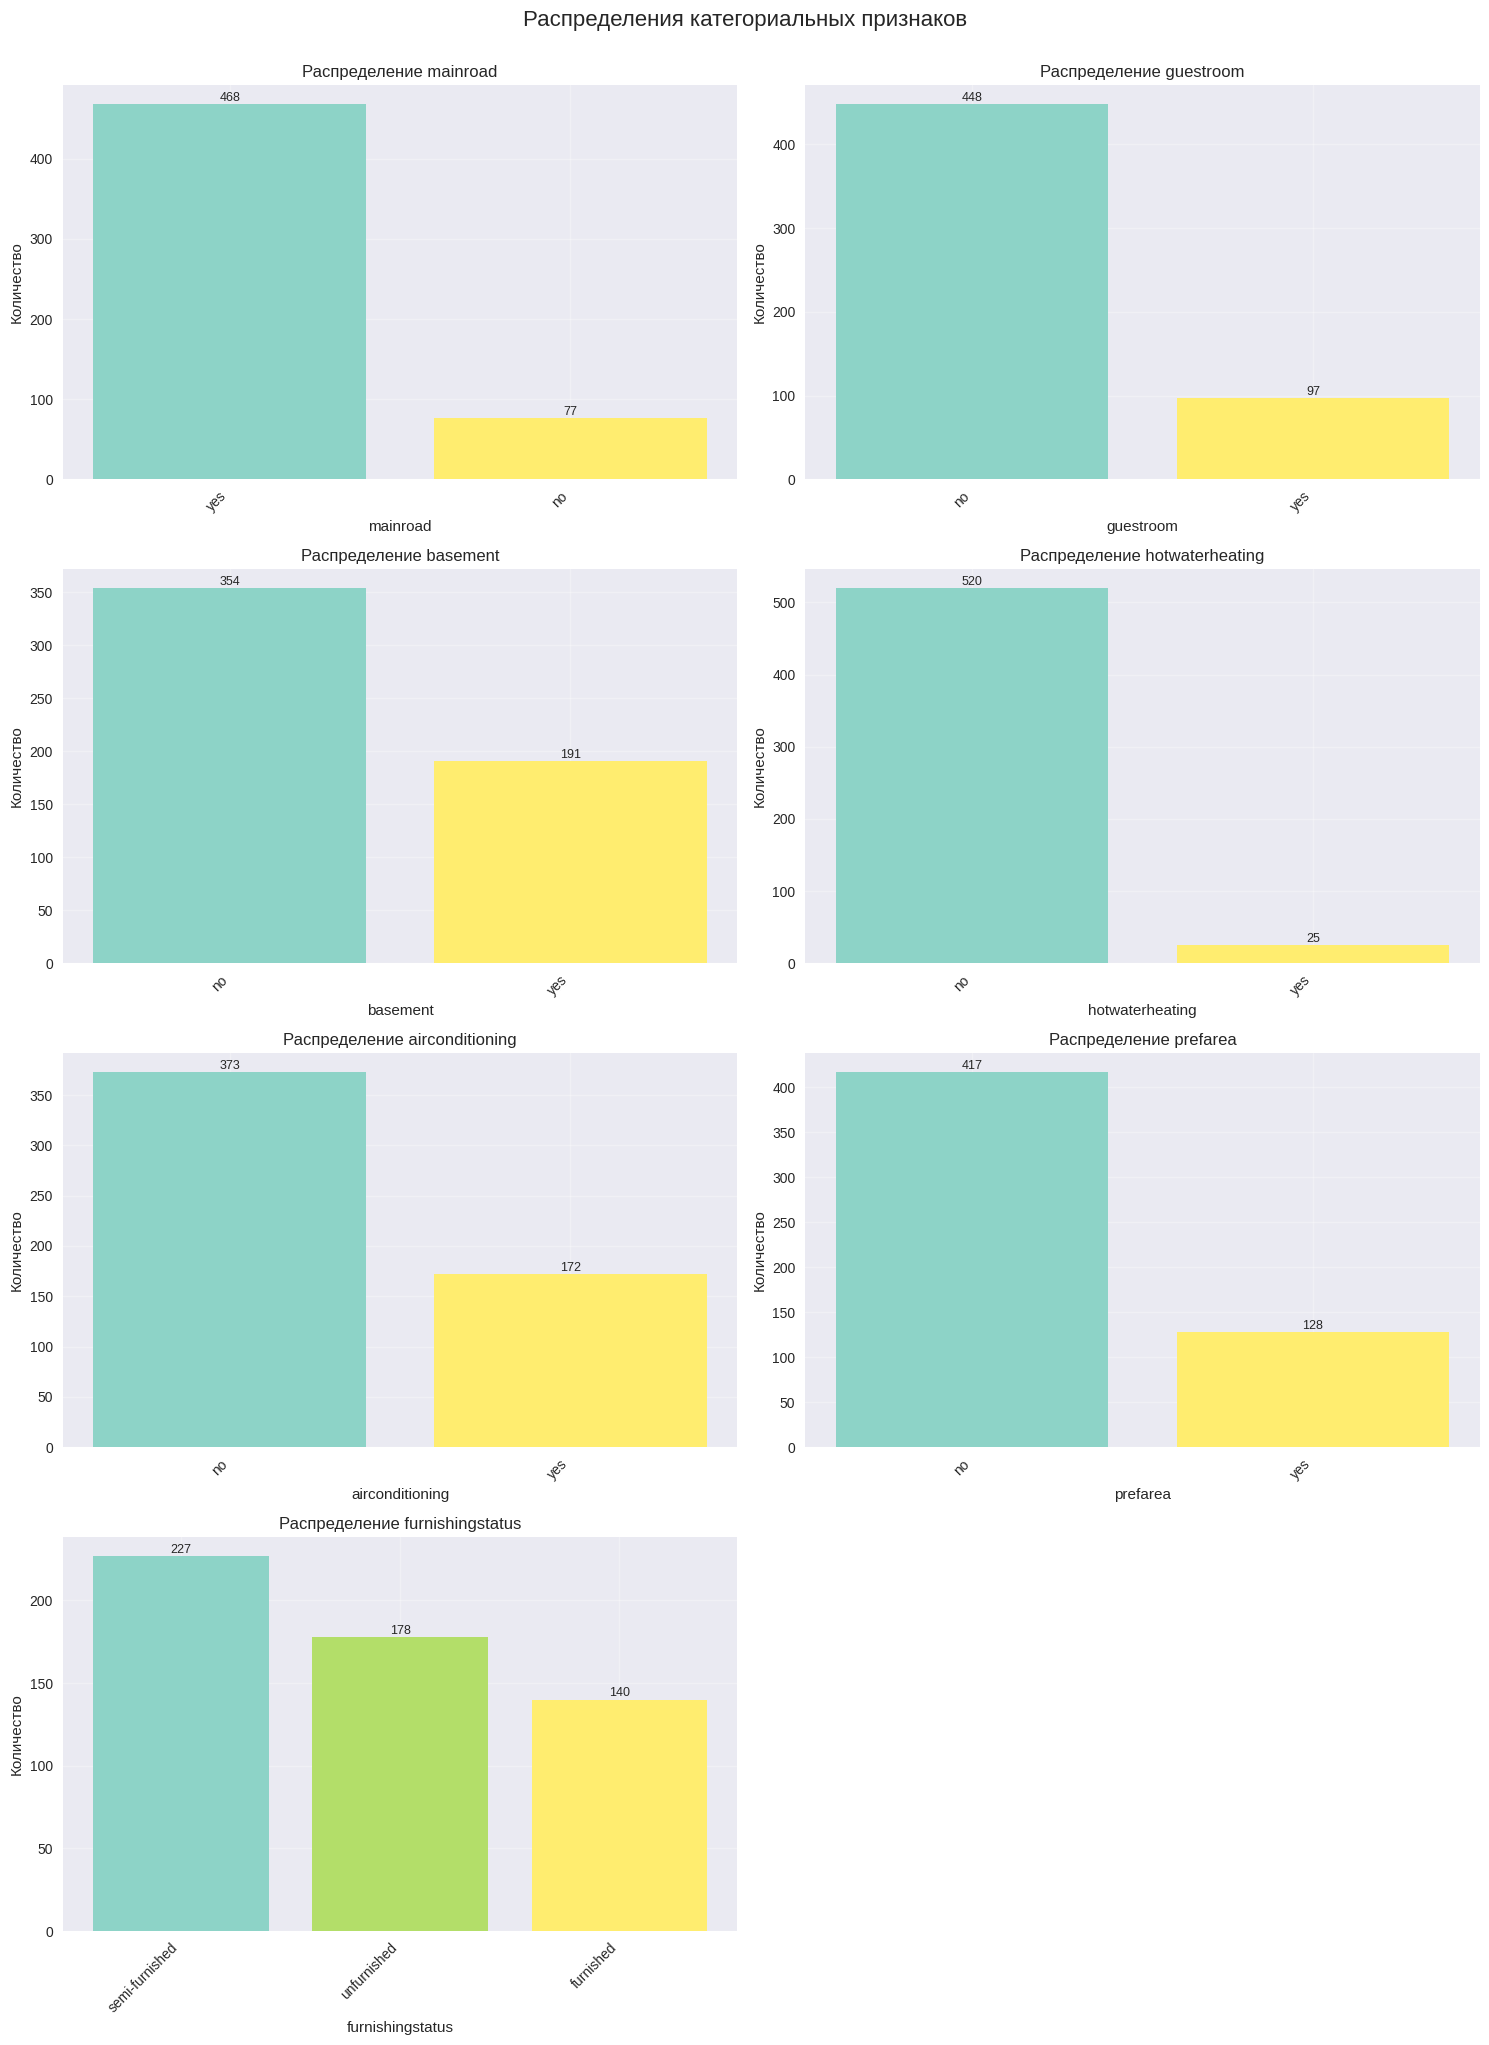


Статистика по цене (price)

Среднее: 4766729.25
Медиана: 4340000.00
Стандартное отклонение: 1870439.62
Минимум: 1750000.00
Максимум: 13300000.00
25-й перцентиль: 3430000.00
75-й перцентиль: 5740000.00
Квартильный размах: 2310000.00


In [63]:
data = pd.read_csv('Housing.csv')
print("\nСтатистика по числовым признакам:")
print(data.describe())

numeric_columns = data.select_dtypes(include=[np.number]).columns
categorical_columns = data.select_dtypes(include=['object']).columns

print("\nМедианы числовых признаков:")
print(data[numeric_columns].median())

print("\nСтандартные отклонения числовых признаков:")
print(data[numeric_columns].std())

print("\nМоды категориальных признаков:")
for col in categorical_columns:
    mode_values = data[col].mode()
    if not mode_values.empty:
        print(f"{col}: {mode_values.iloc[0]}")
    else:
        print(f"{col}: No mode")

plt.figure(figsize=(10, 6))
sns.histplot(data["price"] / 1_000_000, bins=30, kde=True, color="blue", alpha=0.7)
plt.title("Распределение цен на квартиры (в миллионах)")
plt.xlabel("Цена (млн)")
plt.ylabel("Частота")
plt.grid(True, alpha=0.3)
plt.show()


numeric_data = data[numeric_columns]

n_cols = 3
n_rows = (len(numeric_data.columns) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))
for i, column in enumerate(numeric_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data[column], bins=30, kde=True, color="skyblue", edgecolor="black")
    plt.title(f"Распределение {column}")
    plt.xlabel(column)
    plt.ylabel("Частота")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("Распределения числовых признаков датасета Housing", fontsize=16, y=1.02)
plt.show()

categorical_data = data[categorical_columns]

reasonable_categorical = [col for col in categorical_data.columns
                          if data[col].nunique() <= 20]

if reasonable_categorical:
    n_cols_cat = 2
    n_rows_cat = (len(reasonable_categorical) + n_cols_cat - 1) // n_cols_cat

    plt.figure(figsize=(15, n_rows_cat * 5))
    for i, column in enumerate(reasonable_categorical, 1):
        plt.subplot(n_rows_cat, n_cols_cat, i)

        value_counts = data[column].value_counts().head(15)

        if len(value_counts) > 0:
            bars = plt.bar(range(len(value_counts)), value_counts.values,
                           color=plt.cm.Set3(np.linspace(0, 1, len(value_counts))))
            plt.title(f"Распределение {column}")
            plt.xlabel(column)
            plt.ylabel("Количество")
            plt.xticks(range(len(value_counts)), value_counts.index, rotation=45, ha='right')
            plt.grid(True, alpha=0.3)

            for bar, count in zip(bars, value_counts.values):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                         str(count), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.suptitle("Распределения категориальных признаков", fontsize=16, y=1.02)
    plt.show()

print("\nСтатистика по цене (price)\n")
price_stats = {
    'Среднее': data['price'].mean(),
    'Медиана': data['price'].median(),
    'Стандартное отклонение': data['price'].std(),
    'Минимум': data['price'].min(),
    'Максимум': data['price'].max(),
    '25-й перцентиль': data['price'].quantile(0.25),
    '75-й перцентиль': data['price'].quantile(0.75),
    'Квартильный размах': data['price'].quantile(0.75) - data['price'].quantile(0.25)
}

for stat, value in price_stats.items():
    print(f"{stat}: {value:.2f}")


## Выводы по целевой переменной (price)
Распределение цен правостороннее асимметричное (среднее (**4.77 млн**) больше медианы (**4.34 млн**)).
То есть, большинство квартир дешевле, чем кажется по среднему.

Стандартное отклонение = 1.87 млн очень большое. то есть цены в среднем варьируются в диапазоне **4.77 млн +- 1.87 млн**.
квартильный размах задает диапазон **от 3.43 млн до 5.74 млн** между 25-ым и 75-ым процентилем. Большинство квартир относится к этому сегменту.  

Есть выбросы.  
Максимальная цена = 13.3 млн — это сильно выше типичного диапазона.
Такие объекты могут влиять на модель.

Минимальная цена = 1.75 млн.  

In [72]:
binary_cols = ["mainroad", "guestroom", "basement",
               "hotwaterheating", "airconditioning", "prefarea"]


for col in binary_cols:
    if data[col].dtype == "object":
        data[col] = data[col].str.lower().map({"yes": 1, "no": 0})


X = data.drop(["price", "furnishingstatus"], axis=1)

y = data["price"]

print(data.isna().sum())

scaler = StandardScaler()
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = scaler.fit_transform(X[num_cols])

X.head()



price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,1.046726,1.403419,1.421812,1.378217,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.517692,1.804941
1,1.757010,1.403419,5.405809,2.532024,0.405623,-0.465315,-0.734539,-0.219265,1.472618,2.679409,-0.554035
2,2.218232,0.047278,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.517692,1.804941
3,1.083624,1.403419,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,1.472618,2.679409,1.804941
4,1.046726,1.403419,-0.570187,0.224410,0.405623,2.149083,1.361397,-0.219265,1.472618,1.517692,-0.554035


# Предобработка данных
### **1. Проверка и обработка пропусков:**
В датасете отсутствуют пропуски во всех признаках (545 наблюдений в каждом столбце). Дополнительная обработка пропусков не требуется.
### **2. Кодирование категориальных признаков**
Бинарные признаки (mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea) преобразованы в формат 1/0.
Признак furnishingstatus исключен.

Для подготовки данных к моделированию были выделены числовые признаки и выполнена их стандартизация с использованием StandardScaler. Это привело все признаки к единому масштабу (среднее = 0, стандартное отклонение = 1).
После нормализации данные были разделены на обучающую и тестовую выборки в пропорции 80/20 с фиксированным параметром random_state=42 для воспроизводимости результатов.

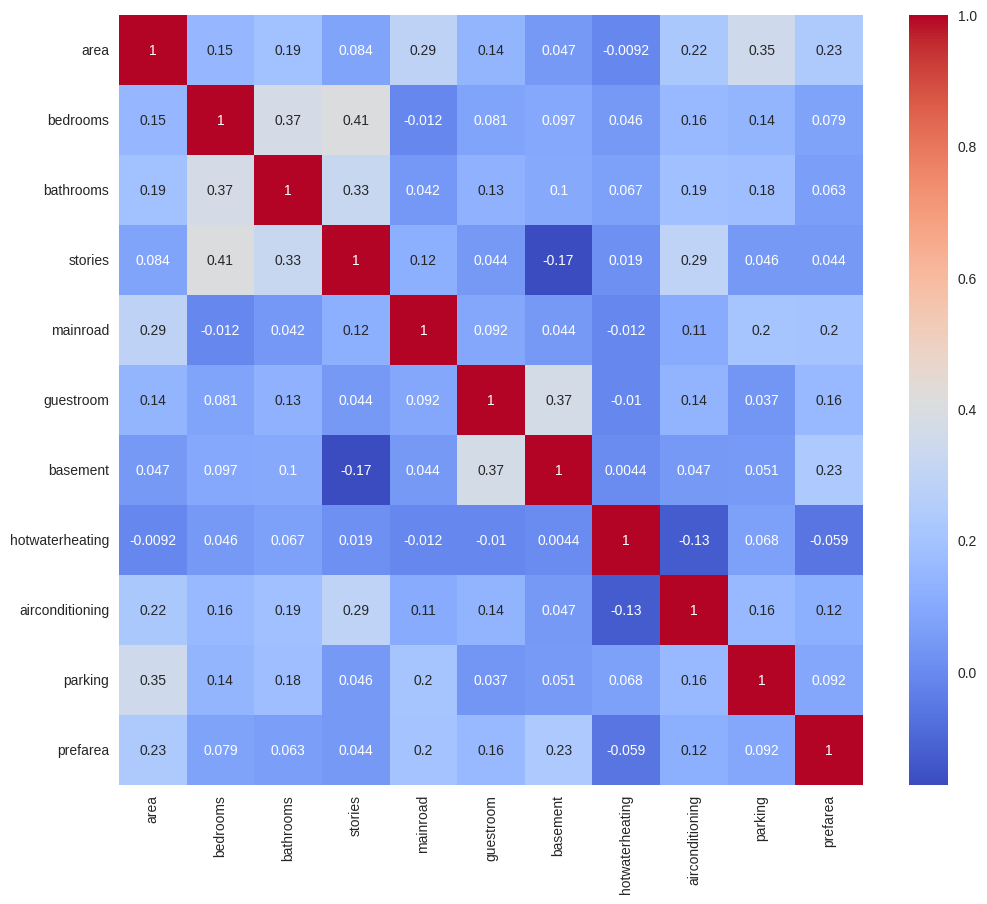

,feature,VIF
0,area,1.321650
1,bedrooms,1.365665
2,bathrooms,1.283520
3,stories,1.476607
4,mainroad,1.163132
5,guestroom,1.210425
6,basement,1.315268
7,hotwaterheating,1.038161
8,airconditioning,1.200862
9,parking,1.201129


In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

corr = X.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data


# Матрица корреляций и VIF
Матрица корреляций показывает отсутствие сильных линейных связей между признаками. Максимальная корреляция составляет около 0.41, что является слабой зависимостью.

Расчёт VIF подтверждает отсутствие мультиколлинеарности: все коэффициенты находятся в диапазоне 1.03–1.47.

Таким образом, матрица признаков хорошо обусловлена, линейная регрессия будет устойчива, а коэффициенты — интерпретируемы.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print('Линейная регрессия')
coefficients = pd.DataFrame({
    "Признак": X.columns,
    "Коэффициент": linear_model.coef_
})

print(coefficients)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

print('Ridge регрессия')
coefficients = pd.DataFrame({
    "Признак": X.columns,
    "Коэффициент": ridge_model.coef_
})

print('\n', coefficients)

lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train, y_train)

print('Lasso регрессия')
coefficients = pd.DataFrame({
    "Признак": X.columns,
    "Коэффициент": lasso_model.coef_
})

print('\n', coefficients)

y_pred_linear = linear_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.7
)

min_price = min(y_test.min(), y_pred_linear.min())
max_price = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    'r--'
)

plt.xlabel("Фактическая цена")
plt.ylabel("Предсказанная цена")
plt.title("Линейная регрессия: предсказанные vs фактические")

plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_ridge,
    alpha=0.7
)

min_price = min(y_test.min(), y_pred_ridge.min())
max_price = max(y_test.max(), y_pred_ridge.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    'r--'
)

plt.xlabel("Фактическая цена")
plt.ylabel("Предсказанная цена")
plt.title("Ridge-регрессия: предсказанные vs фактические")

plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_lasso,
    alpha=0.7
)

min_price = min(y_test.min(), y_pred_lasso.min())
max_price = max(y_test.max(), y_pred_lasso.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    'r--'
)

plt.xlabel("Фактическая цена")
plt.ylabel("Предсказанная цена")
plt.title("Lasso-регрессия: предсказанные vs фактические")

plt.grid(True, alpha=0.3)
plt.show()